In [1]:
import sys
sys.path.append('.')
import samna
import numpy as np
import matplotlib.pyplot as plt
import samna.dynapse1 as dyn1
import dynapse1utils as ut
from netgen import Neuron, NetworkGenerator
import params
from params import set_params
import time
from IPython.display import Image


In [2]:
# open DYNAP-SE1 board to get Dynapse1Model

# The open_dynapse1 utility will initialize communication with the device
# - gui=False: do not open any graphical interface --> the DYNAPSE1 GUI does not work if you connect remotely
# - select_device=True: allow user/device selection if multiple boards are detected --> this is necessary when you are connecting via Zemo, since there is more than 1 board attached

model, _ = ut.open_dynapse1(gui=False, select_device=True)


[0]:  Bus 1 Device 11 Dynapse1DevKit serial_number 00000007
[1]:  Bus 1 Device 30 Dynapse1DevKit serial_number 00000001
[2]:  Bus 1 Device 33 Dynapse1DevKit serial_number 00000092
[3]:  Bus 1 Device 41 Dynapse1DevKit serial_number 00000026
[4]:  Bus 1 Device 52 Dynapse1DevKit serial_number 00000000
0 Dynapse1Wrapper created! libcaer init...
Selected device: 00000007
Sender port: tcp://0.0.0.0:46559
Receiver port: tcp://0.0.0.0:46979
Opened device name: Dynapse1DevKit
SamnaNode ID: 1
PythonNode ID: 2
Clearing chip 0... DONE.
Clearing chip 1... DONE.
Clearing chip 2... DONE.
Clearing chip 3... DONE.


In [3]:
# get Dynapse1 api from the model
api = model.get_dynapse1_api()

In [4]:
# set standard parameters
set_params(model)

In [5]:
config1 = model.get_configuration() 

Remember how to set the parameters. Below you have a reference figure that you can use to understand how setting the "coarse" and "fine" values for the DYNAP-SE1 chip works.

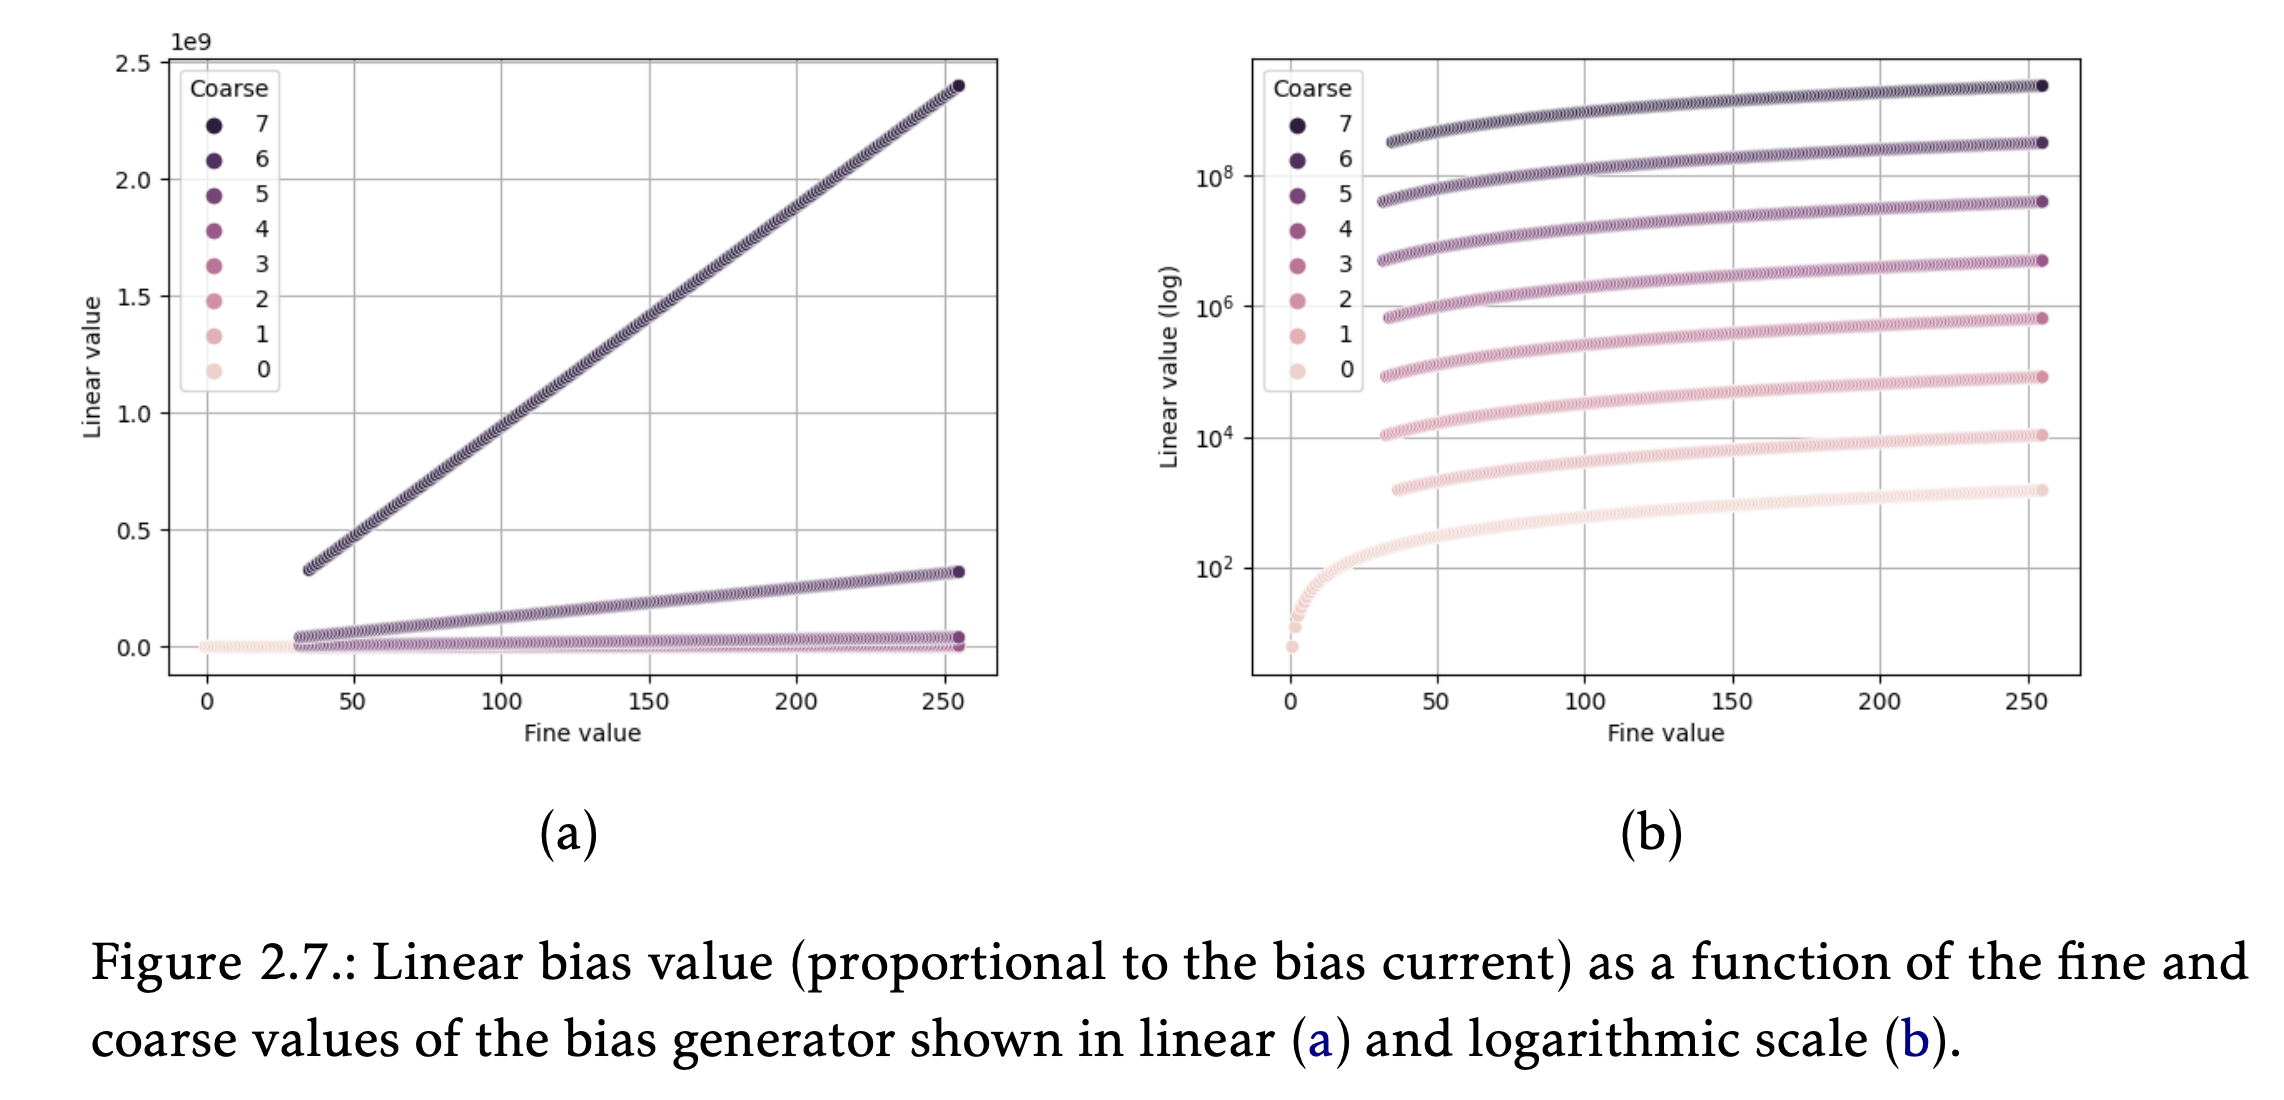

In [6]:
Image("../lab5/params_coarse_fine.png")

In [7]:
# print AMPA weight values

print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_EXC_F_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_F_N'].coarse_value))
print("Fine: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_F_N'].fine_value))

Linear: 752941184.0
Coarse: 7
Fine: 80


In [8]:
param_group = config1.chips[0].cores[0].parameter_group 

In [9]:
# set AMPA (fast excitatory) weight 

param_group.param_map['PS_WEIGHT_EXC_F_N'].fine_value = 160
param_group.param_map['PS_WEIGHT_EXC_F_N'].coarse_value = 4


In [10]:
# print AMPA (fast excitatory) weight values

print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_EXC_F_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_F_N'].coarse_value))
print("Fine: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_F_N'].fine_value))

Linear: 3137255.0
Coarse: 4
Fine: 160


In [11]:
# set NMDA (slow excitatory) weight

param_group.param_map['PS_WEIGHT_EXC_S_N'].fine_value = 180
param_group.param_map['PS_WEIGHT_EXC_S_N'].coarse_value = 4

# param_group.param_map['PS_WEIGHT_EXC_S_N'].fine_value = 0
# param_group.param_map['PS_WEIGHT_EXC_S_N'].coarse_value = 0

In [12]:
# print NMDA (slow excitatory) weight

print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_EXC_S_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_S_N'].coarse_value))
print("Fine: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_S_N'].fine_value))

Linear: 3529412.0
Coarse: 4
Fine: 180


In [13]:
# set GABA B (slow inhibitory) weight

param_group.param_map['PS_WEIGHT_INH_S_N'].fine_value = 150
param_group.param_map['PS_WEIGHT_INH_S_N'].coarse_value = 4

In [14]:
# print GABA B (slow inhibitory) weight

print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_INH_S_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_S_N'].coarse_value))
print("Fine: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_S_N'].fine_value))

Linear: 2941177.0
Coarse: 4
Fine: 150


In [15]:
# set GABA A (fast inhibitory) weight

param_group.param_map['PS_WEIGHT_INH_F_N'].fine_value = 200
param_group.param_map['PS_WEIGHT_INH_F_N'].coarse_value = 4

In [16]:
# print GABA A (fast inhibitory) weight

print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_INH_F_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_F_N'].coarse_value))
print("Fine: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_F_N'].fine_value))

Linear: 3921569.0
Coarse: 4
Fine: 200


In [29]:
# set NMDA (slow exc) tau 
# remember the higher the tau param, the higher the leak, the faster the decay

param_group.param_map['NPDPIE_TAU_S_P'].fine_value = 10
param_group.param_map['NPDPIE_TAU_S_P'].coarse_value = 4

In [18]:
# print NMDA (slow exc) tau 

print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('NPDPIE_TAU_S_P')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_S_P'].coarse_value))
print("Fine: " + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_S_P'].fine_value))

Linear: 137647.0
Coarse: 4
Fine: 7


In [30]:
# # set AMPA (fast exc) tau 

param_group.param_map['NPDPIE_TAU_F_P'].fine_value = 10
param_group.param_map['NPDPIE_TAU_F_P'].coarse_value = 4

In [20]:
# print AMPA (fast exc) tau 

print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('NPDPIE_TAU_F_P')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_F_P'].coarse_value))
print("Fine: " + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_F_P'].fine_value))

Linear: 99412.0
Coarse: 4
Fine: 5


In [34]:
param_group.param_map["NPDPII_TAU_F_P"].coarse_value = 4
param_group.param_map["NPDPII_TAU_F_P"].fine_value = 8

param_group.param_map["NPDPII_TAU_S_P"].coarse_value = 4
param_group.param_map["NPDPII_TAU_S_P"].fine_value = 8

In [22]:
#config1 = model.get_configuration() 

### checl range of params 
param = config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_S_P']
print(param)
dir(param)
type(param.coarse_value)
print(param.coarse_value)

dynapse1::Dynapse1Parameter param_name=NPDPIE_TAU_S_P, coarse_value=4, fine_value=7, type=P.
4


225 NMDA synapses
New configuration applied to DYNAP-SE1!
monitored neurons: [(0, 0, 1), (0, 0, 2), (0, 0, 3), (0, 0, 4), (0, 0, 5), (0, 0, 6), (0, 0, 7), (0, 0, 8), (0, 0, 9), (0, 0, 10), (0, 0, 11), (0, 0, 12), (0, 0, 13), (0, 0, 14), (0, 0, 15), (0, 0, 16), (0, 0, 17), (0, 0, 18), (0, 0, 19), (0, 0, 20), (0, 0, 21), (0, 0, 22), (0, 0, 23), (0, 0, 24), (0, 0, 25), (0, 0, 26), (0, 0, 27), (0, 0, 28), (0, 0, 29), (0, 0, 30), (0, 0, 31), (0, 0, 32), (0, 0, 33), (0, 0, 34), (0, 0, 35), (0, 0, 36), (0, 0, 37), (0, 0, 38), (0, 0, 39), (0, 0, 41), (0, 0, 42), (0, 0, 43), (0, 0, 44), (0, 0, 45), (0, 0, 46), (0, 0, 47), (0, 0, 48), (0, 0, 49), (0, 0, 50), (0, 0, 51), (0, 0, 52), (0, 0, 53), (0, 0, 54), (0, 0, 55), (0, 0, 56), (0, 0, 57), (0, 0, 58), (0, 0, 59), (0, 0, 60), (0, 0, 61), (0, 0, 62), (0, 0, 63), (0, 0, 64), (0, 0, 65), (0, 0, 66), (0, 0, 67), (0, 0, 68), (0, 0, 69), (0, 0, 70), (0, 0, 71), (0, 0, 72), (0, 0, 73), (0, 0, 74), (0, 0, 75), (0, 0, 76), (0, 0, 77), (0, 0, 78), (0, 0, 

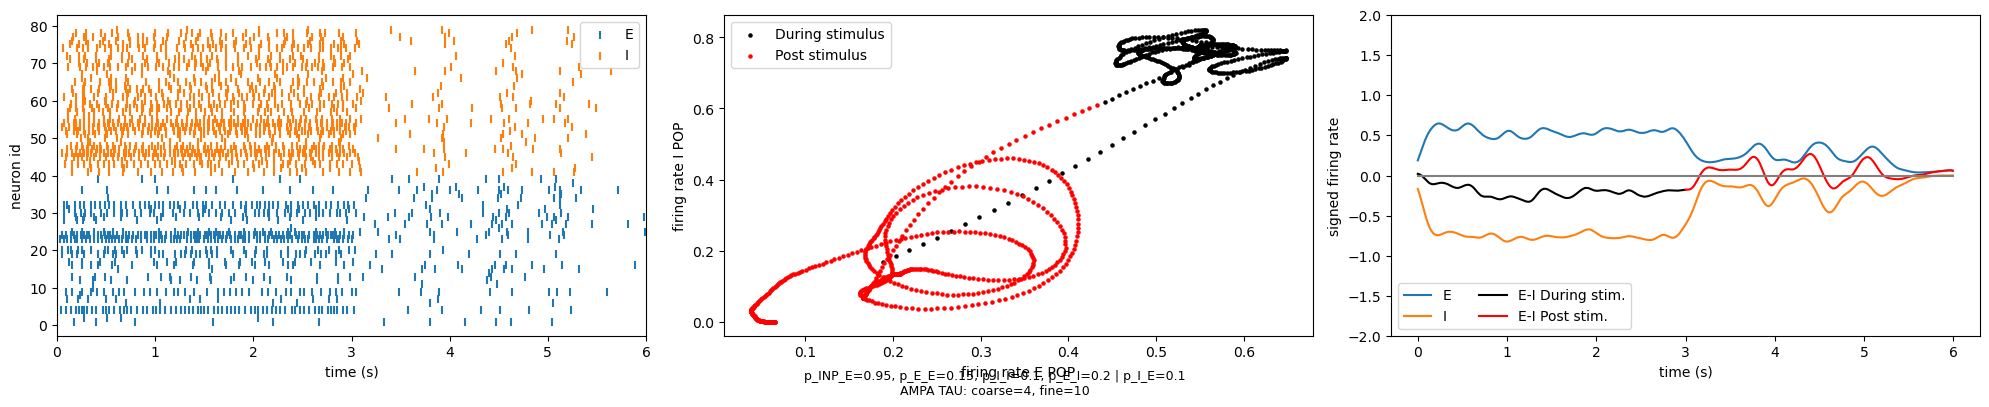

In [36]:
#import importlib # Module to dynamically reload modules
#importlib.reload(params) # Reloads the params module to ensure any changes are recognized

###what does this actually do ? 
model.update_parameter_group(param_group, 0, 0) # update params based on the params you changed 

p_INP_E = 0.95       # Probability of connections from spike generator to excitatory population
p_E_E   = 0.15        # Probability of connections among excitatory neurons
p_I_I   = 0.1           # Probability of connections among inhibitory neurons
p_E_I   = 0.2      # Probability of connections from excitatory to inhibitory
p_I_E   = 0.1          # Probability of connections from inhibitory to excitatory

# p_INP_E = .7            # Probability of connections from spike generator to excitatory population
# p_E_E   = 0.1          # Probability of connections among excitatory neurons
# p_I_I   = 0.5             # Probability of connections among inhibitory neurons
# p_E_I   = 0.2           # Probability of connections from excitatory to inhibitory
# p_I_E   = 0.5 

#### Given 

#model.update_parameter_group(param_group, 0, 0) # update params based on the params you changed 

# p_INP_E = 1             # Probability of connections from spike generator to excitatory population
# p_E_E   = 0.8             # Probability of connections among excitatory neurons
# p_I_I   = 0.0             # Probability of connections among inhibitory neurons
# p_E_I   = 0.5             # Probability of connections from excitatory to inhibitory
# p_I_E   = 0.0             # Probability of connections from inhibitory to excitatory

# We use CHIP 0 in this exercise 
    # remember, there are 4 chips per every blue box. There are 4 cores per every chip. There are 256 neurons per every core.
    
# We are using a SPIKEGEN located  in CORE 1. POPULATION E is in CORE 0. POPULATION I is in CORE 0.
    # when you set up your own EI balanced networks in the future, we advise that you keep the POPULATION E and POPULATION I in different cores to more easily control the parameters

# Create a NetworkGenerator object to build the network configuration:
net_gen = NetworkGenerator()
net_gen.clear_network() # Clear any existing network structure

# We will create a spike generator in chip=0, core=1, neuron=1

spikegen_ids = [(0, 1, 1)]
spikegens = []
for spikegen_id in spikegen_ids:
    spikegens.append(Neuron(spikegen_id[0],spikegen_id[1],spikegen_id[2],True))

# Define the size of the excitatory population and create their neuron IDs:
NE    = 40
E_ids = [(0,0,ni) for ni in range(1,NE)]
neurons_E = []
for nid in E_ids:
    neurons_E.append(Neuron(nid[0],nid[1],nid[2]))


# Define the size of the inhibitory population and create their neuron IDs
NI    = 40
I_ids = [(0,0,ni+NE) for ni in range(1,NI)]
neurons_I = []
for nid in I_ids:
    neurons_I.append(Neuron(nid[0],nid[1],nid[2]))


# connect SPIKEGEN to POPULATION E:
for i in range(int(NE*p_INP_E)-1):
    # Here, we connect from spikegens[0] to neurons_E[i]
    # using the AMPA synapse type
    net_gen.add_connection(spikegens[0], neurons_E[i], dyn1.Dynapse1SynType.AMPA)

# connect POPULATION E to POPULATION E
    # (Connect excitatory neurons among themselves (E to E) with probability p_E_E)
counter=0
for i in range(NE-1):
    for j in range(NE-1):
        if(i!=j and p_E_E > np.random.uniform()):
            counter+=1
            # Use NMDA synapse type for these connections. So you can tune the parameters of the NMDA and AMPA synapses separately
            net_gen.add_connection(neurons_E[i], neurons_E[j], dyn1.Dynapse1SynType.NMDA)
print(str(counter)+" NMDA synapses")
            
# connect POPULATION E to POPULATION I
for i in range(NE-1):
    for j in range(NI-1):
        if(p_E_I > np.random.uniform()):
            net_gen.add_connection(neurons_E[i], neurons_I[j], dyn1.Dynapse1SynType.AMPA)


# connect POPULATION I to POPULATION I 
for i in range(NI-1):
    for j in range(NI-1):
        if(i!=j and p_I_I > np.random.uniform()):
            net_gen.add_connection(neurons_I[i], neurons_I[j], dyn1.Dynapse1SynType.GABA_A)


# connect POPULATION I to POPULATION E
for i in range(NI-1):
    for j in range(NE-1):
        if(p_I_E > np.random.uniform()):
            net_gen.add_connection(neurons_I[i], neurons_E[j], dyn1.Dynapse1SynType.GABA_B)

# make a dynapse1config using the network
new_config = net_gen.make_dynapse1_configuration()

# apply the configuration
model.apply_configuration(new_config)


for rate in [50]:
    D_stim = 3 # stimulus duration (s)
    D_post_stim = 3 # post stimulus duration (s)
    D = D_stim + D_post_stim
    global_poisson_gen_ids = ut.get_global_id_list(spikegen_ids)
    poisson_gen = model.get_poisson_gen()
    poisson_gen.set_chip_id(0)
    poisson_gen.write_poisson_rate_hz(global_poisson_gen_ids[0], rate)
    
    # set parameters
### turned of 
    #set_params(model)#, param_group = param_group) # note here: set_params(model) will revert the params back to the standard params
### newly setted for changing behavior
    set_params(model, param_group = param_group)
    # if you want to use new parameters that you set via this script, you need to use set_params(model, param_group = param_group)
    
    
    # how to get events of selected neurons
    monitored_neurons = E_ids + I_ids
    graph, filter_node, sink_node = ut.create_neuron_select_graph(model, monitored_neurons)

### create graphs have to be stopped____________________________________________
    graph.start()

    # start the poisson gen
    poisson_gen.start()

    # select the neurons to monitor
    print("monitored neurons:", monitored_neurons)
    filter_node.set_neurons(monitored_neurons)

    # clear the buffer
    sink_node.get_events()

    api.reset_timestamp()
    time.sleep(D_stim)

    poisson_gen.stop()
    time.sleep(D_post_stim)
    graph.stop()
    events = sink_node.get_events()
    
### create graphs have to be stopped____________________________________________

    # process the events
    print(len(events),"events.")

    NN = 256 # neurons in 1 core
    spike_id = []
    spike_t  = []
    for evt in events:
        spike_id.append(evt.core_id*NN + evt.neuron_id)
        spike_t.append(evt.timestamp*1e-6)
    spike_id = np.array(spike_id)
    spike_t  = np.array(spike_t) 

    # E mean firing rate
    fs = 200
    binPOP = np.zeros((2,int(D*fs)))
    for i in range(len(events)):
        if(spike_t[i]<D):
            binPOP[spike_id[i]//NE,int(spike_t[i]*fs)]=1

    sigma = 0.01
    x = np.arange(int(-0.2*fs),int(0.2*fs))/fs
    gauss = np.exp(-x**2/sigma)

    binPOP[0] = np.convolve(binPOP[0],gauss,'same')
    binPOP[1] = np.convolve(binPOP[1],gauss,'same')

    f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20,4))

    ax1.scatter(spike_t[spike_id<(NE)],spike_id[spike_id<(NE)],marker='|',label='E')
    ax1.scatter(spike_t[spike_id>(NE)],spike_id[spike_id>(NE)],marker='|',label='I')
    ax1.set_xlabel('time (s)')
    ax1.set_ylabel('neuron id')
    ax1.legend()
    ax1.set_xlim(0,D)


    ax2.scatter(binPOP[0,:int(D_stim*fs)]/NE,binPOP[1,:int(D_stim*fs)]/NI,c='k',s=5,label='During stimulus')
    ax2.scatter(binPOP[0,int(D_stim*fs):]/NE,binPOP[1,int(D_stim*fs):]/NI,c='red',s=5,label='Post stimulus')
    ax2.set_ylabel('firing rate I POP')
    ax2.set_xlabel('firing rate E POP')
    ax2.legend()

    ax3.plot(np.arange(int(D*fs))/fs,binPOP[0]/NE,label='E')
    ax3.plot(np.arange(int(D*fs))/fs,-binPOP[1]/NI,label='I')
    ax3.plot(np.arange(int(D_stim*fs))/fs,binPOP[0,:int(D_stim*fs)]/NE-binPOP[1,:int(D_stim*fs)]/NI,c='k',label='E-I During stim.')
    ax3.plot(np.arange(int(D_post_stim*fs))/fs+int(D_stim*fs)/fs,binPOP[0,int(D_stim*fs):]/NE-binPOP[1,int(D_stim*fs):]/NI,c='red',label='E-I Post stim.')
    ax3.plot([0,D],[0,0],'gray')
    ax3.set_ylabel('signed firing rate')
    ax3.set_xlabel('time (s)')
    ax3.legend(loc='lower left', ncol=2)
    ax3.set_ylim(-2,2)

###write param to pic

    param = param_group.param_map['NPDPIE_TAU_F_P']

    plt.subplots_adjust(bottom=0.1)
    plt.figtext(0.5, 0.001, f"p_INP_E={p_INP_E}, p_E_E={p_E_E}, p_I_I={p_I_I}, p_E_I={p_E_I} | p_I_E={p_I_E}\n"     f"AMPA TAU: coarse={param.coarse_value}, fine={param.fine_value}",ha="center", fontsize=9)

    plt.tight_layout()
    #plt.savefig('EI.png')
    #plt.savefig(f"./plots/NMDA_syn_{counter}_{p_INP_E}_plt.png")
    plt.show()

Can you achieve something similar as the below figure?

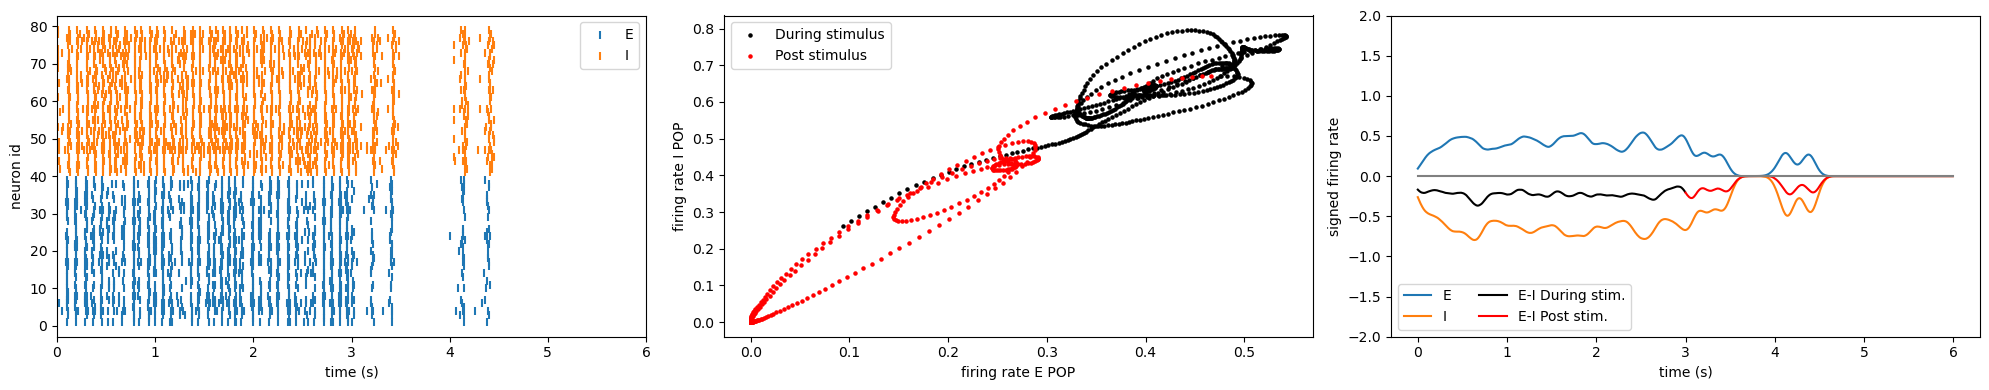

In [24]:
Image("../lab5/EI_balance.png")